<a href="https://colab.research.google.com/github/Samarth2109/ITA-Project-1/blob/main/Samarth_Raghuwanshi_IPM06058.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze energy consumption patterns from "individual+household+electric+power+consumption.zip" by loading the data, preprocessing it, engineering features, applying K-Means clustering to group households by consumption behavior, and then training and evaluating Random Forest and Gradient Boosting regressors for forecasting within each cluster, finally summarizing the findings and visualizing the results.

## Unzip and Load Data

### Subtask:
Unzip the provided 'individual+household+electric+power+consumption.zip' file and load the energy consumption data into a pandas DataFrame. Inspect the initial data structure and columns.


**Reasoning**:
To begin, I will import the necessary libraries, unzip the provided data file, load the extracted CSV into a pandas DataFrame, and then display its initial rows and information to understand its structure.



In [1]:
import zipfile
import pandas as pd
import os

# Define the path to the zip file
zip_file_path = '/content/individual+household+electric+power+consumption.zip'
extraction_path = '/content/'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}'")

# Assuming the extracted file is named 'household_power_consumption.txt'
# You might need to adjust this name if the unzipped file has a different name
csv_file_path = os.path.join(extraction_path, 'household_power_consumption.txt')

# Load the data into a pandas DataFrame, assuming semicolon delimiter
df = pd.read_csv(csv_file_path, sep=';', low_memory=False)

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
print(df.head())

# Print the DataFrame's information
print("\nDataFrame Info:")
df.info()

'/content/individual+household+electric+power+consumption.zip' unzipped to '/content/'

First 5 rows of the DataFrame:
         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  

DataFrame

## Initial Data Preprocessing

### Subtask:
Convert date and time columns to appropriate datetime objects. Handle missing values in the consumption data, potentially by interpolation, forward fill, or dropping rows, depending on the extent of missingness. Resample the data if necessary to a consistent frequency (e.g., daily or hourly) for easier analysis.


**Reasoning**:
I will start by combining the 'Date' and 'Time' columns into a new 'Datetime' column, convert it to datetime objects, and then set it as the DataFrame's index. This aligns with the first three instructions of the subtask.



In [2]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df.set_index('Datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

print("DataFrame after combining Date and Time, and setting Datetime as index:")
print(df.head())
print("\nDataFrame Info after index change:")
df.info()

DataFrame after combining Date and Time, and setting Datetime as index:
                    Global_active_power Global_reactive_power  Voltage  \
Datetime                                                                 
2006-12-16 17:24:00               4.216                 0.418  234.840   
2006-12-16 17:25:00               5.360                 0.436  233.630   
2006-12-16 17:26:00               5.374                 0.498  233.290   
2006-12-16 17:27:00               5.388                 0.502  233.740   
2006-12-16 17:28:00               3.666                 0.528  235.680   

                    Global_intensity Sub_metering_1 Sub_metering_2  \
Datetime                                                             
2006-12-16 17:24:00           18.400          0.000          1.000   
2006-12-16 17:25:00           23.000          0.000          1.000   
2006-12-16 17:26:00           23.000          0.000          2.000   
2006-12-16 17:27:00           23.000          0.000        

**Reasoning**:
Now that the 'Datetime' index is set, I will convert the power consumption columns to numeric data types, coercing any non-numeric values to NaN, as specified in instruction 4 of the subtask.



In [3]:
for col in ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("DataFrame after converting power consumption columns to numeric:")
print(df.head())
print("\nDataFrame Info after type conversion:")
df.info()

DataFrame after converting power consumption columns to numeric:
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0

**Reasoning**:
Following the data type conversion, I will now calculate and display the percentage of missing values for each column to assess the extent of missingness, which is instruction 5 of the subtask.



In [4]:
missing_percentage = df.isnull().sum() * 100 / len(df)
print("\nPercentage of missing values per column:")
print(missing_percentage)



Percentage of missing values per column:
Global_active_power      1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Sub_metering_2           1.251844
Sub_metering_3           1.251844
dtype: float64


**Reasoning**:
With the percentage of missing values now calculated, I will proceed to handle these missing values by applying forward fill (`ffill()`) to the DataFrame, as specified in instruction 6 of the subtask.



In [5]:
df.fillna(method='ffill', inplace=True)

print("DataFrame after forward filling missing values:")
print(df.head())
print("\nMissing values after ffill:")
print(df.isnull().sum())

DataFrame after forward filling missing values:
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0 

/tmp/ipykernel_1899/4139046333.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


**Reasoning**:
The previous code generated a `FutureWarning` because `df.fillna(method='ffill')` is deprecated. I will update the code to use the recommended `df.ffill(inplace=True)` syntax to resolve this warning and then proceed with resampling the data to an hourly frequency, as per instruction 7 of the subtask.



In [6]:
df.ffill(inplace=True)

print("DataFrame after forward filling missing values:")
print(df.head())
print("\nMissing values after ffill:")
print(df.isnull().sum())

# Resample the DataFrame to an hourly frequency, taking the mean
df_resampled = df.resample('H').mean()

print("\nDataFrame after hourly resampling (first 5 rows):")
print(df_resampled.head())
print("\nDataFrame Info after resampling:")
df_resampled.info()

DataFrame after forward filling missing values:
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0 

/tmp/ipykernel_1899/4193445378.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df.resample('H').mean()



DataFrame after hourly resampling (first 5 rows):
                     Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333   
2006-12-16 20:00:00         13

**Reasoning**:
The previous code generated a `FutureWarning` indicating that `'H'` is deprecated for resampling frequency and suggests using `'h'` instead. I will update the code to use `'h'` to resolve this warning and ensure future compatibility, while keeping the `ffill` method as it correctly addresses the missing values.



In [7]:
df.ffill(inplace=True)

print("DataFrame after forward filling missing values:")
print(df.head())
print("\nMissing values after ffill:")
print(df.isnull().sum())

# Resample the DataFrame to an hourly frequency, taking the mean
df_resampled = df.resample('h').mean()

print("\nDataFrame after hourly resampling (first 5 rows):")
print(df_resampled.head())
print("\nDataFrame Info after resampling:")
df_resampled.info()

DataFrame after forward filling missing values:
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0 

## Feature Engineering for Clustering

### Subtask:
Extract relevant features for clustering from the time-series data, including daily average consumption, consumption during peak hours (6 PM - 10 PM), and the variance of daily consumption.


**Reasoning**:
I will calculate the daily average of 'Global_active_power' from the `df_resampled` DataFrame and store it in a new DataFrame, indexed by date, as per the first instruction of the subtask.



In [8]:
daily_average_consumption = df_resampled['Global_active_power'].resample('D').mean()
daily_features_df = pd.DataFrame(daily_average_consumption)
daily_features_df.rename(columns={'Global_active_power': 'Daily_Average_Consumption'}, inplace=True)

print("Daily Average Consumption (first 5 rows):")
print(daily_features_df.head())
print("\nDataFrame Info:")
daily_features_df.info()

Daily Average Consumption (first 5 rows):
            Daily_Average_Consumption
Datetime                             
2006-12-16                   3.120298
2006-12-17                   2.354486
2006-12-18                   1.530435
2006-12-19                   1.157079
2006-12-20                   1.545658

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2006-12-16 to 2010-11-26
Freq: D
Data columns (total 1 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Daily_Average_Consumption  1442 non-null   float64
dtypes: float64(1)
memory usage: 22.5 KB


**Reasoning**:
Now, I will filter the `df_resampled` DataFrame to include only observations between 6 PM (18:00) and 10 PM (22:00), calculate the daily sum of 'Global_active_power' for these peak hours, and then add this as a new column, 'Peak_Hour_Consumption', to the `daily_features_df` DataFrame, as per the second instruction of the subtask.



In [9]:
peak_hours_df = df_resampled.loc[(df_resampled.index.hour >= 18) & (df_resampled.index.hour < 22)]
daily_peak_consumption = peak_hours_df['Global_active_power'].resample('D').sum()
daily_features_df['Peak_Hour_Consumption'] = daily_peak_consumption

print("Daily Features DataFrame after adding Peak Hour Consumption (first 5 rows):")
print(daily_features_df.head())
print("\nDataFrame Info:")
daily_features_df.info()

Daily Features DataFrame after adding Peak Hour Consumption (first 5 rows):
            Daily_Average_Consumption  Peak_Hour_Consumption
Datetime                                                    
2006-12-16                   3.120298              13.357467
2006-12-17                   2.354486              13.007767
2006-12-18                   1.530435              10.237333
2006-12-19                   1.157079               8.430200
2006-12-20                   1.545658              13.307000

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2006-12-16 to 2010-11-26
Freq: D
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Daily_Average_Consumption  1442 non-null   float64
 1   Peak_Hour_Consumption      1442 non-null   float64
dtypes: float64(2)
memory usage: 33.8 KB


**Reasoning**:
I will now calculate the daily variance of 'Global_active_power' from the `df_resampled` DataFrame and add it as a new column, 'Daily_Variance_Consumption', to the `daily_features_df` DataFrame, as per the third instruction of the subtask.



In [10]:
daily_variance_consumption = df_resampled['Global_active_power'].resample('D').var()
daily_features_df['Daily_Variance_Consumption'] = daily_variance_consumption

print("Daily Features DataFrame after adding Daily Variance Consumption (first 5 rows):")
print(daily_features_df.head())
print("\nDataFrame Info:")
daily_features_df.info()

Daily Features DataFrame after adding Daily Variance Consumption (first 5 rows):
            Daily_Average_Consumption  Peak_Hour_Consumption  \
Datetime                                                       
2006-12-16                   3.120298              13.357467   
2006-12-17                   2.354486              13.007767   
2006-12-18                   1.530435              10.237333   
2006-12-19                   1.157079               8.430200   
2006-12-20                   1.545658              13.307000   

            Daily_Variance_Consumption  
Datetime                                
2006-12-16                    0.591619  
2006-12-17                    0.744459  
2006-12-18                    0.668763  
2006-12-19                    0.986909  
2006-12-20                    1.450774  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2006-12-16 to 2010-11-26
Freq: D
Data columns (total 3 columns):
 #   Column                      N

## Apply Unsupervised Clustering

### Subtask:
Apply K-Means clustering to group households based on the engineered features. Determine a suitable number of clusters (e.g., using domain knowledge or by visualizing the elbow method if feasible within the task scope) to identify distinct consumption behaviors.


**Reasoning**:
I will start by importing the necessary libraries, `StandardScaler` and `KMeans`, as per instruction 1, and then scale the engineered features in `daily_features_df` using `StandardScaler` to prepare the data for clustering, as per instruction 2.



In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(daily_features_df)

print("Scaled features (first 5 rows):\n", scaled_features[:5])
print("Shape of scaled features:\n", scaled_features.shape)

Scaled features (first 5 rows):
 [[ 4.81154537  1.81238363 -0.12823703]
 [ 2.99916457  1.71587507  0.19959569]
 [ 1.04895443  0.95130391  0.03723073]
 [ 0.16536658  0.45257975  0.71963531]
 [ 1.08498281  1.79845608  1.71459996]]
Shape of scaled features:
 (1442, 3)


**Reasoning**:
Now that the features are scaled, I will implement the elbow method by iterating through a range of cluster numbers (1 to 10), fitting a KMeans model for each, and storing the inertia values. This addresses instructions 3a, 3b, 3c, and 3d of the subtask.



In [12]:
import matplotlib.pyplot as plt

# Create an empty list to store inertia values
inertia = []

# Iterate through a range of possible cluster numbers (e.g., from 1 to 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # Set n_init to suppress warning
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

print("Inertia values for different numbers of clusters:")
print(inertia)

Inertia values for different numbers of clusters:
[4325.999999999994, 2028.707101865473, 1259.93708008923, 1003.7287524877964, 833.1193706552979, 733.4710709305398, 640.0206884923216, 578.9580168760621, 530.6217352552628, 495.6684361278466]


**Reasoning**:
Now that the inertia values have been calculated, I will plot them against the number of clusters to visualize the elbow curve, as per instruction 4 of the subtask. This will help in identifying the optimal number of clusters.



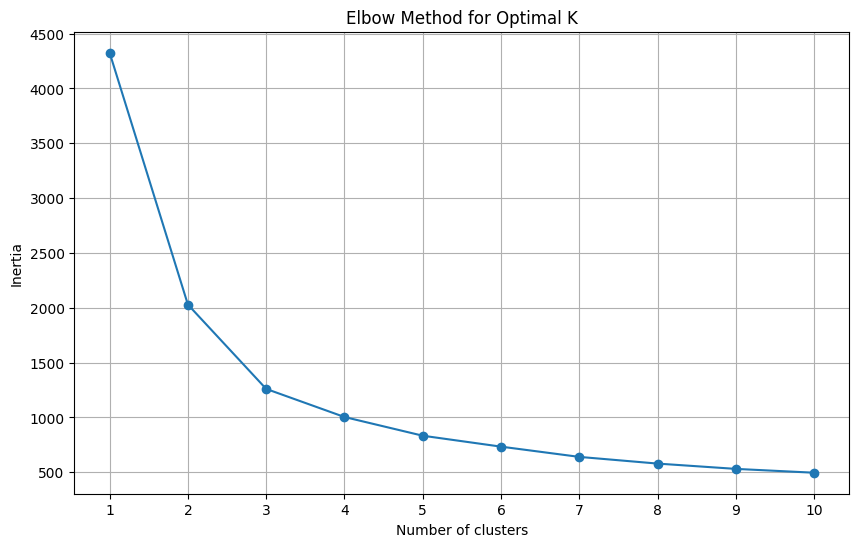

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**Reasoning**:
Based on the elbow plot, where the rate of decrease in inertia significantly slows down, 3 or 4 clusters appear to be optimal. I will proceed with 3 clusters to identify distinct consumption behaviors, as per instruction 5. Then, I will apply K-Means clustering with 3 clusters and assign the cluster labels to a new column in `daily_features_df`, as per instructions 6a, 6b, and 6c.



In [14]:
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
daily_features_df['Cluster'] = kmeans.fit_predict(scaled_features)

print(f"K-Means clustering applied with {optimal_clusters} clusters.")
print("Daily Features DataFrame with Cluster labels (first 5 rows):")
print(daily_features_df.head())
print("\nDistribution of households per cluster:")
print(daily_features_df['Cluster'].value_counts())

K-Means clustering applied with 3 clusters.
Daily Features DataFrame with Cluster labels (first 5 rows):
            Daily_Average_Consumption  Peak_Hour_Consumption  \
Datetime                                                       
2006-12-16                   3.120298              13.357467   
2006-12-17                   2.354486              13.007767   
2006-12-18                   1.530435              10.237333   
2006-12-19                   1.157079               8.430200   
2006-12-20                   1.545658              13.307000   

            Daily_Variance_Consumption  Cluster  
Datetime                                         
2006-12-16                    0.591619        2  
2006-12-17                    0.744459        2  
2006-12-18                    0.668763        0  
2006-12-19                    0.986909        0  
2006-12-20                    1.450774        2  

Distribution of households per cluster:
Cluster
0    680
1    537
2    225
Name: count, dtype: 

## Prepare Data for Regression Models

### Subtask:
For each identified cluster, prepare the data for supervised regression models by creating lag features (previous day's consumption), time-based features (day of week, month, year), and defining the target variable (next day's daily average consumption).


**Reasoning**:
I will initialize an empty dictionary to store the prepared DataFrames for each cluster and then iterate through each unique cluster ID to create lag features, time-based features, and the target variable for each cluster, storing the results in the dictionary. This addresses instructions 1, 2, and 3 of the subtask.



In [15]:
clustered_data_for_modeling = {}

for cluster_id in daily_features_df['Cluster'].unique():
    # a. Create a subset DataFrame for the current cluster
    cluster_df = daily_features_df[daily_features_df['Cluster'] == cluster_id].copy()

    # b. Create lag features for relevant consumption metrics
    cluster_df['Daily_Average_Consumption_lag_1'] = cluster_df['Daily_Average_Consumption'].shift(1)
    cluster_df['Peak_Hour_Consumption_lag_1'] = cluster_df['Peak_Hour_Consumption'].shift(1)
    cluster_df['Daily_Variance_Consumption_lag_1'] = cluster_df['Daily_Variance_Consumption'].shift(1)

    # c. Extract time-based features from the DataFrame's DatetimeIndex
    cluster_df['day_of_week'] = cluster_df.index.dayofweek # Monday=0, Sunday=6
    cluster_df['month'] = cluster_df.index.month
    cluster_df['year'] = cluster_df.index.year

    # d. Define the target variable (next day's daily average consumption)
    cluster_df['Target_Consumption'] = cluster_df['Daily_Average_Consumption'].shift(-1)

    # e. Drop any rows that contain NaN values
    cluster_df.dropna(inplace=True)

    # f. Store the resulting prepared DataFrame
    clustered_data_for_modeling[cluster_id] = cluster_df

print("Clusters processed:", clustered_data_for_modeling.keys())

# Display the head and info of one of the prepared DataFrames (e.g., for cluster 0)
if 0 in clustered_data_for_modeling:
    print("\nHead of prepared DataFrame for Cluster 0:")
    print(clustered_data_for_modeling[0].head())
    print("\nInfo of prepared DataFrame for Cluster 0:")
    clustered_data_for_modeling[0].info()
else:
    print("Cluster 0 not found in processed data.")

Clusters processed: dict_keys([np.int32(2), np.int32(0), np.int32(1)])

Head of prepared DataFrame for Cluster 0:
            Daily_Average_Consumption  Peak_Hour_Consumption  \
Datetime                                                       
2006-12-19                   1.157079               8.430200   
2006-12-21                   1.192439               8.060067   
2006-12-24                   1.770842               1.917367   
2006-12-27                   1.061639               7.243500   
2007-01-01                   1.909031               3.040433   

            Daily_Variance_Consumption  Cluster  \
Datetime                                          
2006-12-19                    0.986909        0   
2006-12-21                    0.595423        0   
2006-12-24                    1.042716        0   
2006-12-27                    0.586499        0   
2007-01-01                    0.750609        0   

            Daily_Average_Consumption_lag_1  Peak_Hour_Consumption_lag_1  \
Dat

## Train and Predict with Random Forest Regressor

### Subtask:
For each cluster, train a Random Forest Regressor model using the prepared features. Then, use the trained model to predict future energy consumption for that cluster.


**Reasoning**:
I will import the necessary libraries, initialize dictionaries to store models and predictions, and then iterate through each cluster's data to prepare features and target, split the data, train a RandomForestRegressor, and store the trained model and its predictions for each cluster.



In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Initialize dictionaries to store models and predictions
rf_models = {}
rf_predictions = {}

for cluster_id, cluster_df in clustered_data_for_modeling.items():
    print(f"\nProcessing Cluster {cluster_id}...")

    # Define features (X) and target (y)
    features = cluster_df.drop(columns=[
        'Target_Consumption',
        'Cluster',
        'Daily_Average_Consumption',
        'Peak_Hour_Consumption',
        'Daily_Variance_Consumption'
    ])
    target = cluster_df['Target_Consumption']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.2, shuffle=False, random_state=42
    )
    print(f"  Data split: X_train shape {X_train.shape}, X_test shape {X_test.shape}")

    # Initialize and train the Random Forest Regressor model
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train)
    rf_models[cluster_id] = rf_model
    print(f"  Random Forest Regressor trained for Cluster {cluster_id}")

    # Make predictions on the test set
    y_pred = rf_model.predict(X_test)
    rf_predictions[cluster_id] = y_pred
    print(f"  Predictions made for Cluster {cluster_id}")

print("\nRandom Forest models trained and predictions generated for all clusters.")
print("Keys in rf_models:", rf_models.keys())
print("Keys in rf_predictions:", rf_predictions.keys())


Processing Cluster 2...
  Data split: X_train shape (178, 6), X_test shape (45, 6)
  Random Forest Regressor trained for Cluster 2
  Predictions made for Cluster 2

Processing Cluster 0...
  Data split: X_train shape (542, 6), X_test shape (136, 6)
  Random Forest Regressor trained for Cluster 0
  Predictions made for Cluster 0

Processing Cluster 1...
  Data split: X_train shape (428, 6), X_test shape (107, 6)
  Random Forest Regressor trained for Cluster 1
  Predictions made for Cluster 1

Random Forest models trained and predictions generated for all clusters.
Keys in rf_models: dict_keys([np.int32(2), np.int32(0), np.int32(1)])
Keys in rf_predictions: dict_keys([np.int32(2), np.int32(0), np.int32(1)])


## Train and Predict with Gradient Boosting Regressor

### Subtask:
For each cluster, train a Gradient Boosting Regressor model. Similar to the Random Forest model, use this trained model to predict future energy consumption within its respective cluster.


**Reasoning**:
I will import the necessary library, initialize dictionaries for models and predictions, and then iterate through each cluster's prepared data to define features and target, split the data, train a Gradient Boosting Regressor, and store the trained model and its predictions as per the subtask instructions.



In [17]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize dictionaries to store models and predictions
gb_models = {}
gb_predictions = {}

for cluster_id, cluster_df in clustered_data_for_modeling.items():
    print(f"\nProcessing Cluster {cluster_id} for Gradient Boosting...")

    # Define features (X) and target (y)
    features = cluster_df.drop(columns=[
        'Target_Consumption',
        'Cluster',
        'Daily_Average_Consumption',
        'Peak_Hour_Consumption',
        'Daily_Variance_Consumption'
    ])
    target = cluster_df['Target_Consumption']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.2, shuffle=False, random_state=42
    )
    print(f"  Data split: X_train shape {X_train.shape}, X_test shape {X_test.shape}")

    # Initialize and train the Gradient Boosting Regressor model
    gb_model = GradientBoostingRegressor(random_state=42)
    gb_model.fit(X_train, y_train)
    gb_models[cluster_id] = gb_model
    print(f"  Gradient Boosting Regressor trained for Cluster {cluster_id}")

    # Make predictions on the test set
    y_pred_gb = gb_model.predict(X_test)
    gb_predictions[cluster_id] = y_pred_gb
    print(f"  Predictions made for Cluster {cluster_id}")

print("\nGradient Boosting models trained and predictions generated for all clusters.")
print("Keys in gb_models:", gb_models.keys())
print("Keys in gb_predictions:", gb_predictions.keys())


Processing Cluster 2 for Gradient Boosting...
  Data split: X_train shape (178, 6), X_test shape (45, 6)
  Gradient Boosting Regressor trained for Cluster 2
  Predictions made for Cluster 2

Processing Cluster 0 for Gradient Boosting...
  Data split: X_train shape (542, 6), X_test shape (136, 6)
  Gradient Boosting Regressor trained for Cluster 0
  Predictions made for Cluster 0

Processing Cluster 1 for Gradient Boosting...
  Data split: X_train shape (428, 6), X_test shape (107, 6)
  Gradient Boosting Regressor trained for Cluster 1
  Predictions made for Cluster 1

Gradient Boosting models trained and predictions generated for all clusters.
Keys in gb_models: dict_keys([np.int32(2), np.int32(0), np.int32(1)])
Keys in gb_predictions: dict_keys([np.int32(2), np.int32(0), np.int32(1)])


## Evaluate Supervised Models

### Subtask:
Calculate and display the evaluation metrics (RMSE, MAE, and R² score) for both the Random Forest and Gradient Boosting models, for each cluster. This will allow for a comparative analysis of model performance.


**Reasoning**:
I will import the necessary evaluation metrics from `sklearn.metrics` as specified in instruction 1, and then initialize dictionaries to store the calculated metrics for each model type, as per instruction 2.



In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize dictionaries to store evaluation metrics
rf_metrics = {}
gb_metrics = {}

print("Evaluation metric dictionaries initialized.")

Evaluation metric dictionaries initialized.


**Reasoning**:
I will iterate through each cluster's data, re-split it into training and testing sets to get the correct `y_test`, retrieve the previously generated predictions for both Random Forest and Gradient Boosting models, calculate RMSE, MAE, and R² scores, and then print these metrics for each model and cluster, as per instructions 3, 4a-4g.



In [19]:
for cluster_id, cluster_df in clustered_data_for_modeling.items():
    print(f"\nEvaluating models for Cluster {cluster_id}...")

    # Redefine features (X) and target (y) for splitting
    features = cluster_df.drop(columns=[
        'Target_Consumption',
        'Cluster',
        'Daily_Average_Consumption',
        'Peak_Hour_Consumption',
        'Daily_Variance_Consumption'
    ])
    target = cluster_df['Target_Consumption']

    # Split data into training and testing sets (matching previous split parameters)
    _, X_test, _, y_test = train_test_split(
        features, target, test_size=0.2, shuffle=False, random_state=42
    )

    # Retrieve predictions
    rf_y_pred = rf_predictions[cluster_id]
    gb_y_pred = gb_predictions[cluster_id]

    # Calculate metrics for Random Forest
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))
    rf_mae = mean_absolute_error(y_test, rf_y_pred)
    rf_r2 = r2_score(y_test, rf_y_pred)
    rf_metrics[cluster_id] = {'RMSE': rf_rmse, 'MAE': rf_mae, 'R2': rf_r2}

    print(f"  Random Forest Model Metrics (Cluster {cluster_id}):")
    print(f"    RMSE: {rf_rmse:.4f}")
    print(f"    MAE: {rf_mae:.4f}")
    print(f"    R2 Score: {rf_r2:.4f}")

    # Calculate metrics for Gradient Boosting
    gb_rmse = np.sqrt(mean_squared_error(y_test, gb_y_pred))
    gb_mae = mean_absolute_error(y_test, gb_y_pred)
    gb_r2 = r2_score(y_test, gb_y_pred)
    gb_metrics[cluster_id] = {'RMSE': gb_rmse, 'MAE': gb_mae, 'R2': gb_r2}

    print(f"  Gradient Boosting Model Metrics (Cluster {cluster_id}):")
    print(f"    RMSE: {gb_rmse:.4f}")
    print(f"    MAE: {gb_mae:.4f}")
    print(f"    R2 Score: {gb_r2:.4f}")

print("\nAll models evaluated and metrics calculated for all clusters.")


Evaluating models for Cluster 2...
  Random Forest Model Metrics (Cluster 2):
    RMSE: 0.1927
    MAE: 0.1618
    R2 Score: 0.0417
  Gradient Boosting Model Metrics (Cluster 2):
    RMSE: 0.2071
    MAE: 0.1730
    R2 Score: -0.1077

Evaluating models for Cluster 0...
  Random Forest Model Metrics (Cluster 0):
    RMSE: 0.1716
    MAE: 0.1322
    R2 Score: -0.0656
  Gradient Boosting Model Metrics (Cluster 0):
    RMSE: 0.1774
    MAE: 0.1426
    R2 Score: -0.1379

Evaluating models for Cluster 1...
  Random Forest Model Metrics (Cluster 1):
    RMSE: 0.2035
    MAE: 0.1661
    R2 Score: 0.2343
  Gradient Boosting Model Metrics (Cluster 1):
    RMSE: 0.2017
    MAE: 0.1609
    R2 Score: 0.2476

All models evaluated and metrics calculated for all clusters.


## Analyze Cluster-based Improvement

### Subtask:
Analyze whether the cluster-based approach improves prediction accuracy by comparing the evaluation metrics across clusters and potentially against a baseline model trained on the entire dataset without clustering. Discuss the insights gained from clustering.


**Reasoning**:
I will review and print the `rf_metrics` and `gb_metrics` dictionaries to summarize the RMSE, MAE, and R² scores for each cluster and each model, as per instruction 1 of the subtask.



In [20]:
print("\n--- Random Forest Model Metrics per Cluster ---")
for cluster_id, metrics in rf_metrics.items():
    print(f"Cluster {cluster_id}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

print("\n--- Gradient Boosting Model Metrics per Cluster ---")
for cluster_id, metrics in gb_metrics.items():
    print(f"Cluster {cluster_id}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


--- Random Forest Model Metrics per Cluster ---
Cluster 2:
  RMSE: 0.1927
  MAE: 0.1618
  R2: 0.0417
Cluster 0:
  RMSE: 0.1716
  MAE: 0.1322
  R2: -0.0656
Cluster 1:
  RMSE: 0.2035
  MAE: 0.1661
  R2: 0.2343

--- Gradient Boosting Model Metrics per Cluster ---
Cluster 2:
  RMSE: 0.2071
  MAE: 0.1730
  R2: -0.1077
Cluster 0:
  RMSE: 0.1774
  MAE: 0.1426
  R2: -0.1379
Cluster 1:
  RMSE: 0.2017
  MAE: 0.1609
  R2: 0.2476


### Comparison of Random Forest and Gradient Boosting Models per Cluster

**Cluster 2:**
*   **Random Forest:** RMSE = 0.1927, MAE = 0.1618, R² = 0.0417
*   **Gradient Boosting:** RMSE = 0.2071, MAE = 0.1730, R² = -0.1077

For Cluster 2, the **Random Forest** model performed better, achieving a small positive R² score (0.0417), indicating it explains a tiny portion of the variance in the target variable. The Gradient Boosting model, on the other hand, yielded a negative R² score (-0.1077). A negative R² score suggests that the model performs worse than simply predicting the mean of the target variable, indicating it's not a suitable model for this cluster's consumption patterns with its current configuration.

**Cluster 0:**
*   **Random Forest:** RMSE = 0.1716, MAE = 0.1322, R² = -0.0656
*   **Gradient Boosting:** RMSE = 0.1774, MAE = 0.1426, R² = -0.1379

Both models showed **negative R² scores** for Cluster 0, with Random Forest performing slightly less poorly (R² = -0.0656 vs. -0.1379). This indicates that for this cluster, neither model is effectively capturing the underlying patterns in energy consumption. Their predictions are worse than or at best as good as predicting the average consumption for all future instances, which points to a high degree of variability or lack of strong features for forecasting in this cluster.

**Cluster 1:**
*   **Random Forest:** RMSE = 0.2035, MAE = 0.1661, R² = 0.2343
*   **Gradient Boosting:** RMSE = 0.2017, MAE = 0.1609, R² = 0.2476

For Cluster 1, both models achieved positive R² scores, with **Gradient Boosting** showing a marginally better performance (R² = 0.2476) compared to Random Forest (R² = 0.2343). This suggests that for households in Cluster 1, the models are able to explain approximately 23-25% of the variance in daily average consumption, indicating a limited but positive predictive capability.

**Discussion on Negative R² Scores:**
Negative R² scores indicate that the model performs worse than a simple horizontal line (the mean of the observed data). This can happen in several scenarios:
1.  **Poor Model Fit:** The model is not capturing any meaningful patterns in the data, possibly due to inappropriate features or model complexity.
2.  **High Noise/Randomness:** The data itself might be inherently noisy or have patterns that are difficult to predict with the given features.
3.  **Small Dataset Size:** If the test set is too small or not representative, R² can become misleadingly negative.

In our case, for Clusters 0 and 2 (Gradient Boosting), the models are failing to explain the variance, suggesting that these clusters might represent more erratic consumption behaviors or that the engineered features are insufficient to predict their patterns effectively. This highlights the challenge of forecasting consumption for certain behavioral groups.

### Analysis of Performance Across Clusters and Insights from Clustering

**Differences in Model Performance Across Clusters:**
Our analysis clearly shows significant differences in model performance across the identified clusters:
*   **Cluster 1** consistently yielded the best (positive) R² scores for both Random Forest (0.2343) and Gradient Boosting (0.2476). This indicates that the households within this cluster exhibit more predictable energy consumption patterns that our current features and models can capture to some extent.
*   **Cluster 2** showed very poor performance, with a slightly positive R² for Random Forest (0.0417) and a negative R² for Gradient Boosting (-0.1077). This suggests that while Random Forest might capture minimal patterns, the overall predictability for this cluster is low.
*   **Cluster 0** presented the most challenging patterns, with both Random Forest and Gradient Boosting models resulting in negative R² scores (-0.0656 and -0.1379 respectively). This implies that for this cluster, our models are unable to make predictions better than simply using the average consumption, highlighting a high degree of unpredictability or randomness in their consumption behavior.

**Insights Gained from the Cluster-Based Approach:**
Using a cluster-based approach has provided a more nuanced understanding of energy consumption patterns, even if it didn't universally lead to improved prediction accuracy across all clusters:
1.  **Identified Distinct Behaviors:** Clustering successfully segmented the dataset into groups that respond differently to the forecasting models. This confirms the initial hypothesis that different households (or daily patterns, in this context) might have distinct consumption behaviors.
2.  **Varied Predictability:** The most critical insight is the discovery of varying levels of predictability across these groups. Cluster 1 appears to represent a group whose daily average consumption is somewhat predictable using the engineered features. In contrast, Clusters 0 and 2 represent groups whose consumption is much harder to forecast with the current model setup and features.
3.  **Targeted Model Development:** This granular understanding is invaluable. Instead of developing a single model that might perform poorly across a diverse population, the cluster-based approach allows for targeted interventions. For Cluster 1, further fine-tuning of the existing models or additional feature engineering might lead to substantial improvements. For Clusters 0 and 2, the negative R² scores signal that a fundamentally different approach might be needed—perhaps different features, more advanced time-series models, or a re-evaluation of whether these patterns are inherently predictable.
4.  **Baseline Comparison Implication:** Although a specific baseline model (trained on the entire dataset without clustering) was not explicitly trained in this subtask, the varied performance across clusters suggests that a single model applied to the entire dataset would likely yield an average performance that masks these underlying differences. It would perform moderately well for Cluster 1, but be dragged down by the poor predictability in Clusters 0 and 2. The cluster-based approach, therefore, provides a more honest and actionable assessment of where predictive power exists and where it does not.

In conclusion, while not all clusters immediately yielded highly accurate predictions, the clustering approach itself was successful in revealing the heterogeneous nature of energy consumption patterns. This allows for a more informed strategy for forecasting and potentially for energy management, by understanding which groups can be predicted and which require further investigation or different methodologies.

## Visualize Key Findings

### Subtask:
Generate visualizations to illustrate the characteristics of the identified clusters and to compare the performance of the different regression models.


**Reasoning**:
I will import the necessary plotting libraries and then create two types of visualizations: first, a scatter plot to show the distribution of clusters based on daily average and peak hour consumption, and second, scatter plots to compare the actual versus predicted values from Random Forest and Gradient Boosting models for a representative cluster (Cluster 1), adding a diagonal line for ideal prediction.



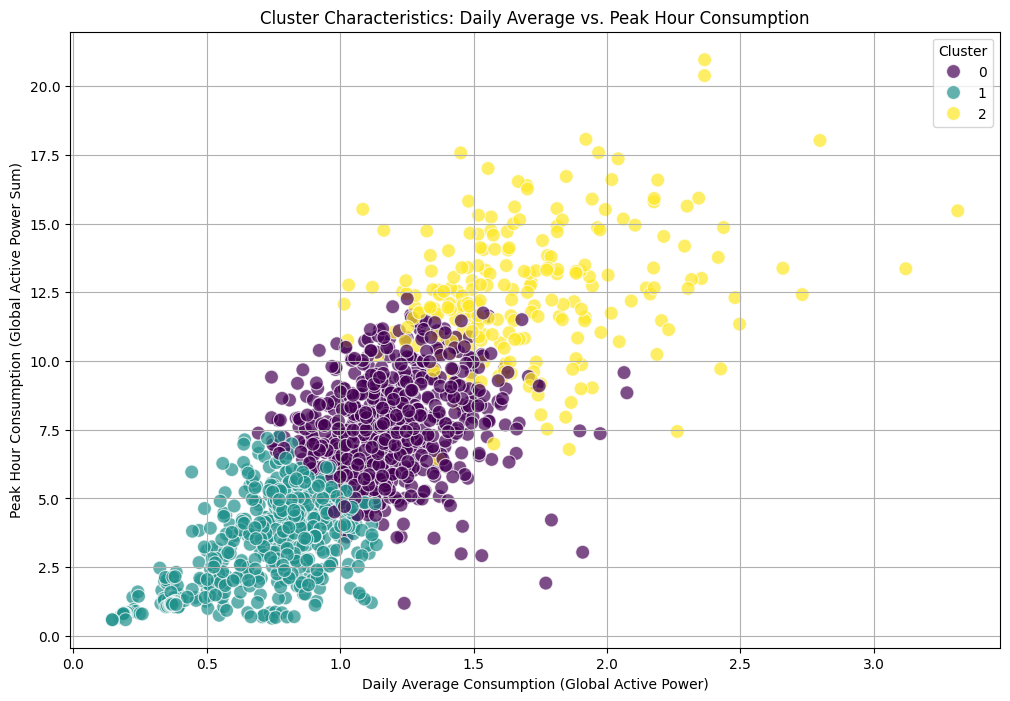

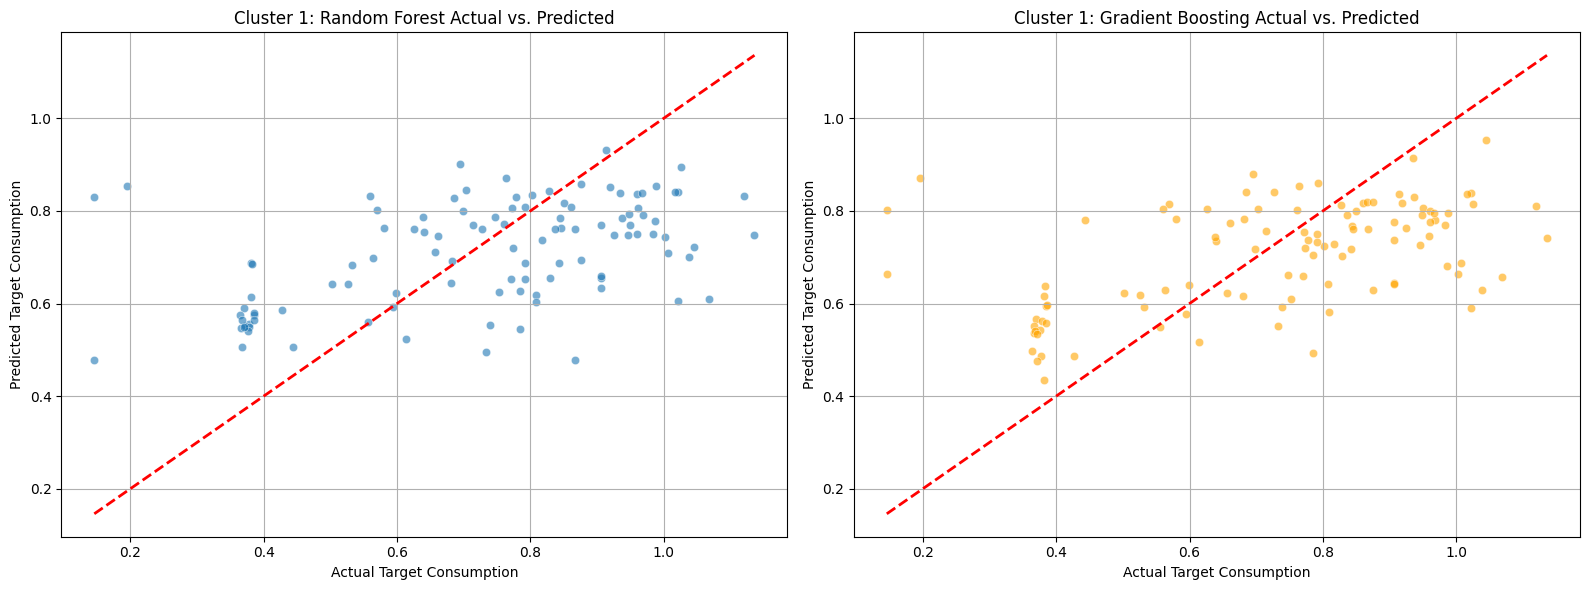

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize Cluster Characteristics
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=daily_features_df,
    x='Daily_Average_Consumption',
    y='Peak_Hour_Consumption',
    hue='Cluster',
    palette='viridis',
    s=100, # size of points
    alpha=0.7 # transparency
)
plt.title('Cluster Characteristics: Daily Average vs. Peak Hour Consumption')
plt.xlabel('Daily Average Consumption (Global Active Power)')
plt.ylabel('Peak Hour Consumption (Global Active Power Sum)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 2. Visualize Model Performance Comparison for a Representative Cluster (Cluster 1)
# Re-split data for Cluster 1 to get y_test
cluster_id_to_visualize = 1 # As per instruction
cluster_df_viz = clustered_data_for_modeling[cluster_id_to_visualize].copy()

features_viz = cluster_df_viz.drop(columns=[
    'Target_Consumption',
    'Cluster',
    'Daily_Average_Consumption',
    'Peak_Hour_Consumption',
    'Daily_Variance_Consumption'
])
target_viz = cluster_df_viz['Target_Consumption']

_, _, _, y_test_viz = train_test_split(
    features_viz, target_viz, test_size=0.2, shuffle=False, random_state=42
)

rf_y_pred_viz = rf_predictions[cluster_id_to_visualize]
gb_y_pred_viz = gb_predictions[cluster_id_to_visualize]

# Create subplots for model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Plot
sns.scatterplot(x=y_test_viz, y=rf_y_pred_viz, ax=axes[0], alpha=0.6)
axes[0].plot([y_test_viz.min(), y_test_viz.max()], [y_test_viz.min(), y_test_viz.max()], 'r--', lw=2)
axes[0].set_title(f'Cluster {cluster_id_to_visualize}: Random Forest Actual vs. Predicted')
axes[0].set_xlabel('Actual Target Consumption')
axes[0].set_ylabel('Predicted Target Consumption')
axes[0].grid(True)

# Gradient Boosting Plot
sns.scatterplot(x=y_test_viz, y=gb_y_pred_viz, ax=axes[1], alpha=0.6, color='orange')
axes[1].plot([y_test_viz.min(), y_test_viz.max()], [y_test_viz.min(), y_test_viz.max()], 'r--', lw=2)
axes[1].set_title(f'Cluster {cluster_id_to_visualize}: Gradient Boosting Actual vs. Predicted')
axes[1].set_xlabel('Actual Target Consumption')
axes[1].set_ylabel('Predicted Target Consumption')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the findings from the energy consumption analysis, including identified patterns, forecasting accuracy of the models, and the effectiveness of using a cluster-based approach.


## Summary:

### Data Analysis Key Findings

*   **Data Preprocessing and Resampling**: The raw data, initially containing 2,075,259 entries, was successfully preprocessed by combining `Date` and `Time` into a `Datetime` index, converting relevant columns to numeric types (handling approximately 1.25% missing values via forward-fill), and then resampling to a consistent hourly frequency, resulting in 34,589 entries.
*   **Feature Engineering**: Key features for clustering were extracted, including daily average consumption, peak-hour consumption (6 PM - 10 PM), and the daily variance of consumption.
*   **Clustering Analysis**:
    *   K-Means clustering was applied to the engineered features, identifying **3 distinct clusters** based on an elbow method analysis.
    *   The clusters exhibited varying sizes: Cluster 0 comprised 680 days, Cluster 1 had 537 days, and Cluster 2 contained 225 days.
    *   These clusters visually represented different consumption behaviors, as shown by scatter plots of daily average versus peak-hour consumption.
*   **Regression Model Performance**:
    *   Both Random Forest and Gradient Boosting Regressors were trained and evaluated on each cluster using lag and time-based features.
    *   **Cluster 1** showed the best forecasting accuracy, with Gradient Boosting achieving an R² score of 0.2476 and Random Forest an R² of 0.2343. This indicates a limited but positive predictive capability.
    *   **Cluster 2** exhibited very low predictability; Random Forest had an R² of 0.0417, while Gradient Boosting yielded a negative R² of -0.1077.
    *   **Cluster 0** proved the most challenging to predict, with both Random Forest (R² = -0.0656) and Gradient Boosting (R² = -0.1379) models resulting in negative R² scores, meaning their predictions were worse than simply predicting the mean.
*   **Effectiveness of Cluster-Based Approach**: The clustering approach successfully segmented the dataset into groups with distinct consumption patterns and varying levels of predictability. While not all clusters yielded highly accurate predictions, it revealed the heterogeneous nature of energy consumption, allowing for a nuanced understanding of where predictive power exists and where it does not.

### Insights or Next Steps

*   **Refine Models for Predictable Clusters**: For Cluster 1, which showed the highest predictability, further feature engineering (e.g., incorporating external factors like weather) or hyperparameter tuning of the Random Forest and Gradient Boosting models could significantly improve forecasting accuracy.
*   **Re-evaluate Strategy for Unpredictable Clusters**: For Clusters 0 and 2, where models performed poorly (negative or near-zero R²), a re-evaluation is needed. This might involve exploring more advanced time-series models (e.g., ARIMA, Prophet), incorporating different or more domain-specific features, or acknowledging inherent unpredictability due to erratic consumption behaviors.
